# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

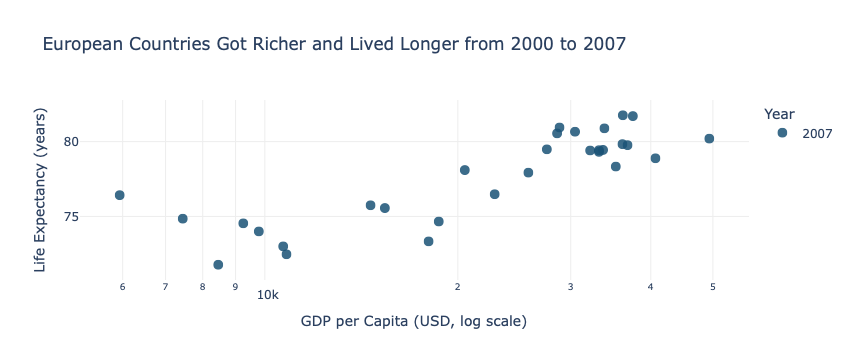

In [27]:
# Task 1
# YOUR CODE HERE
df_europe = df.loc[
    (df['continent'] == 'Europe') & (df['year'].isin([2000, 2007]))
].copy()

df_europe['year'] = df_europe['year'].astype(str)

fig1 = px.scatter(
    df_europe,
    x='gdpPercap',
    y='lifeExp',
    color='year',
    color_discrete_map={'2000': '#90b4ce', '2007': '#1a5276'},  # 2 colours only
    hover_name='country',
    log_x=True,                                                  # Rule 4: log scale
    labels={
        'gdpPercap': 'GDP per Capita (USD, log scale)',
        'lifeExp': 'Life Expectancy (years)',
        'year': 'Year'
    },
    title='European Countries Got Richer and Lived Longer from 2000 to 2007',  # Rule 5: insight title
)

fig1.update_traces(marker=dict(size=10, opacity=0.85))
fig1.update_layout(
    legend_title_text='Year',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    yaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)

fig1.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


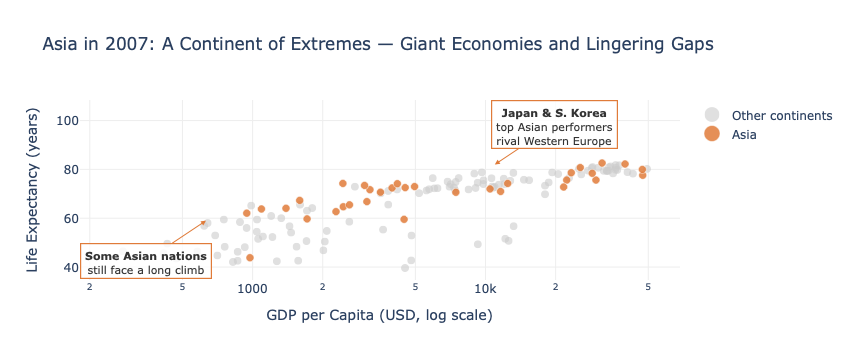

In [26]:
# Task 2
# YOUR CODE HERE
import plotly.graph_objects as go
df_2007 = df[df['year'] == 2007].copy()

HIGHLIGHT = 'Asia'

df_grey  = df_2007[df_2007['continent'] != HIGHLIGHT]
df_color = df_2007[df_2007['continent'] == HIGHLIGHT]

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=df_grey['gdpPercap'],
    y=df_grey['lifeExp'],
    mode='markers',
    name='Other continents',
    text=df_grey['country'],
    hovertemplate=(
        '<b>%{text}</b><br>'
        'GDP/cap: $%{x:,.0f}<br>'
        'Life exp: %{y:.1f} yrs<extra></extra>'
    ),
    marker=dict(
        size=df_grey['pop'] / 1_500_000,  
        sizemode='area',
        sizeref=2. * df_2007['pop'].max() / (40 ** 2),  
        sizemin=4,
        color='#cccccc',
        opacity=0.6,
        line=dict(width=0),
    )
))

fig2.add_trace(go.Scatter(
    x=df_color['gdpPercap'],
    y=df_color['lifeExp'],
    mode='markers',
    name='Asia',
    text=df_color['country'],
    hovertemplate=(
        '<b>%{text}</b><br>'
        'GDP/cap: $%{x:,.0f}<br>'
        'Life exp: %{y:.1f} yrs<extra></extra>'
    ),
    marker=dict(
        size=df_color['pop'] / 1_500_000,
        sizemode='area',
        sizeref=2. * df_2007['pop'].max() / (40 ** 2),
        sizemin=4,
        color='#e07b39',   
        opacity=0.85,
        line=dict(width=0.5, color='white'),
    )
))

fig2.update_xaxes(
    type='log',
    title='GDP per Capita (USD, log scale)',
    showgrid=True, gridcolor='#eeeeee'
)
fig2.update_yaxes(
    title='Life Expectancy (years)',
    showgrid=True, gridcolor='#eeeeee'
)

# --- Annotation: story insight ---
fig2.add_annotation(
    x=4.04,            
    y=82,
    text="<b>Japan & S. Korea</b><br>top Asian performers<br>rival Western Europe",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e07b39',
    ax=60, ay=-40,
    font=dict(size=11, color='#333'),
    bgcolor='rgba(255,255,255,0.8)',
    bordercolor='#e07b39',
    borderwidth=1.2,
    borderpad=4,
)

fig2.add_annotation(
    x=2.8,             
    y=59,
    text="<b>Some Asian nations</b><br>still face a long climb",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e07b39',
    ax=-60, ay=40,
    font=dict(size=11, color='#333'),
    bgcolor='rgba(255,255,255,0.8)',
    bordercolor='#e07b39',
    borderwidth=1.2,
    borderpad=4,
)

fig2.update_layout(
    title="Asia in 2007: A Continent of Extremes — Giant Economies and Lingering Gaps",  # insight title
    plot_bgcolor='white',
    legend=dict(title=''),
)

fig2.show()